# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Bangladesh Market Price Dataset](https://www.kaggle.com/datasets/muhtadinmunjinsirat/bangladesh-agricultural-market-price-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('bangladesh_market_price.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Division,District,Market,Crop,Variety,Group,Arrivals (Tonnes),Min Price (BDT/Quintal),Max Price (BDT/Quintal),Price (BDT/Quintal),Reported Date,Quality_Grade,Market_Demand,Stock_Availability,Market_Type,Season
0,Barishal,Patuakhali,Patuakhali Sadar Market,Barley,BARI Barley-7,Barley Flour,1,2340,2536,2438,8/25/2022,Grade A,Medium,Medium,Retail,Winter
1,Khulna,Satkhira,Satkhira Market,Barley,BARI Barley-7,Barley Flour,13.5,4172,4520,4346,3/23/2024,Grade A,Low,Medium,Retail,Winter
2,Khulna,Khulna,Khulna New Market,Barley,BARI Barley-7,Barley Flour,2,9715,10525,10120,9/20/2023,Grade C,High,High,Wholesale,Winter
3,Khulna,Satkhira,Satkhira Market,Barley,BARI Barley-7,Barley Flour,3,6207,6725,6466,1/10/2022,Grade A,Medium,Low,Retail,Winter
4,Rajshahi,Naogaon,Naogaon Sadar Market,Barley,BARI Barley-7,Barley Flour,400,4437,4807,4622,3/21/2024,Grade A,Low,Medium,Retail,Winter


## last Five row

In [4]:
df.tail()

,Division,District,Market,Crop,Variety,Group,Arrivals (Tonnes),Min Price (BDT/Quintal),Max Price (BDT/Quintal),Price (BDT/Quintal),Reported Date,Quality_Grade,Market_Demand,Stock_Availability,Market_Type,Season
3995,Chattogram,Noakhali,Maijdee Bazar,Wheat,BARI Gom-33,Wheat Flour,103,7242,7846,7544,1/8/2024,Grade C,Medium,High,Wholesale,Winter
3996,Dhaka,Narayanganj,Chashara Market,Wheat,BARI Gom-33,Wheat Flour,2,5393,5843,5618,3/25/2021,Grade A,Medium,Low,Retail,Winter
3997,Dhaka,Tangail,Tangail Sadar Market,Wheat,BARI Gom-33,Wheat Flour,11,1824,1976,1900,11/24/2021,Grade B,Medium,Low,Retail,Winter
3998,Dhaka,Manikganj,Manikganj Bazar,Wheat,BARI Gom-33,Wheat Flour,5,2164,2344,2254,11/21/2022,Grade C,High,Low,Retail,Winter
3999,Dhaka,Dhaka,Karwan Bazar,Wheat,BARI Gom-33,Wheat Flour,4,1710,1852,1781,2/18/2022,Grade A,Low,High,Retail,Winter


## Shape of our dataset

In [5]:
df.shape

(4000, 16)

## List out all columns

In [6]:
df.columns

Index(['Division', 'District', 'Market', 'Crop', 'Variety', 'Group',
       'Arrivals (Tonnes)', 'Min Price (BDT/Quintal)',
       'Max Price (BDT/Quintal)', 'Price (BDT/Quintal)', 'Reported Date',
       'Quality_Grade', 'Market_Demand', 'Stock_Availability', 'Market_Type',
       'Season'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Division                   object
District                   object
Market                     object
Crop                       object
Variety                    object
Group                      object
Arrivals (Tonnes)          object
Min Price (BDT/Quintal)     int64
Max Price (BDT/Quintal)     int64
Price (BDT/Quintal)         int64
Reported Date              object
Quality_Grade              object
Market_Demand              object
Stock_Availability         object
Market_Type                object
Season                     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Division                 4000 non-null   object
 1   District                 4000 non-null   object
 2   Market                   4000 non-null   object
 3   Crop                     4000 non-null   object
 4   Variety                  4000 non-null   object
 5   Group                    4000 non-null   object
 6   Arrivals (Tonnes)        4000 non-null   object
 7   Min Price (BDT/Quintal)  4000 non-null   int64 
 8   Max Price (BDT/Quintal)  4000 non-null   int64 
 9   Price (BDT/Quintal)      4000 non-null   int64 
 10  Reported Date            4000 non-null   object
 11  Quality_Grade            4000 non-null   object
 12  Market_Demand            4000 non-null   object
 13  Stock_Availability       4000 non-null   object
 14  Market_Type              4000 non-null  

## Check Null Value

In [9]:
df.isnull().sum()

Division                   0
District                   0
Market                     0
Crop                       0
Variety                    0
Group                      0
Arrivals (Tonnes)          0
Min Price (BDT/Quintal)    0
Max Price (BDT/Quintal)    0
Price (BDT/Quintal)        0
Reported Date              0
Quality_Grade              0
Market_Demand              0
Stock_Availability         0
Market_Type                0
Season                     0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Min Price (BDT/Quintal),Max Price (BDT/Quintal),Price (BDT/Quintal)
count,4000.000000,4000.000000,4000.000000
mean,4750.690000,5146.586000,4948.638000
std,2541.102578,2752.849833,2646.976193
min,795.000000,861.000000,828.000000
25%,2399.500000,2599.500000,2499.500000
50%,4569.500000,4949.500000,4759.500000
75%,6182.000000,6698.000000,6440.000000
max,12876.000000,13948.000000,13412.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

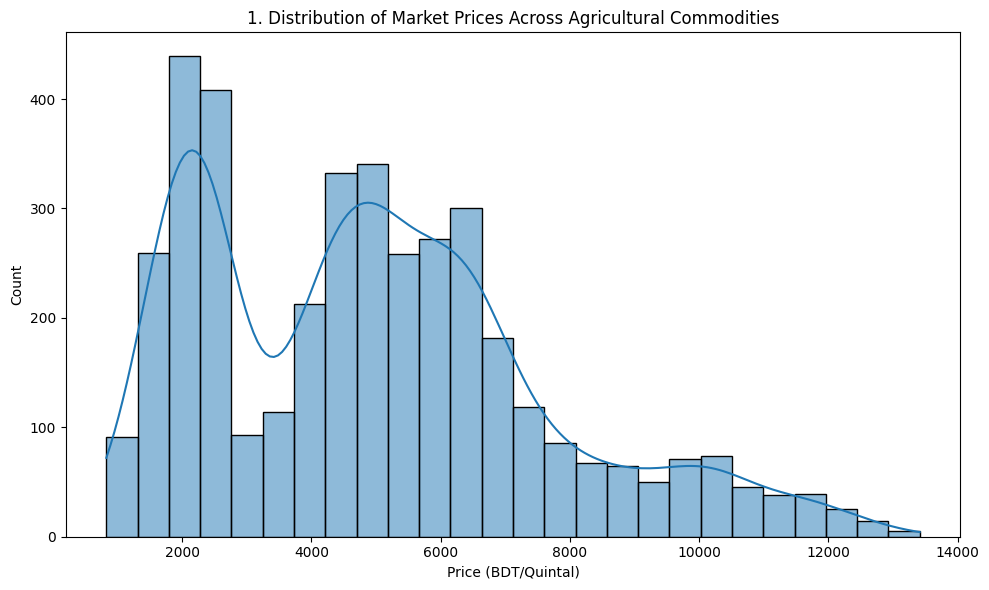

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Price (BDT/Quintal)', kde=True)
plt.title(f'{plot_no}. Distribution of Market Prices Across Agricultural Commodities')
show_fig()
plot_no += 1

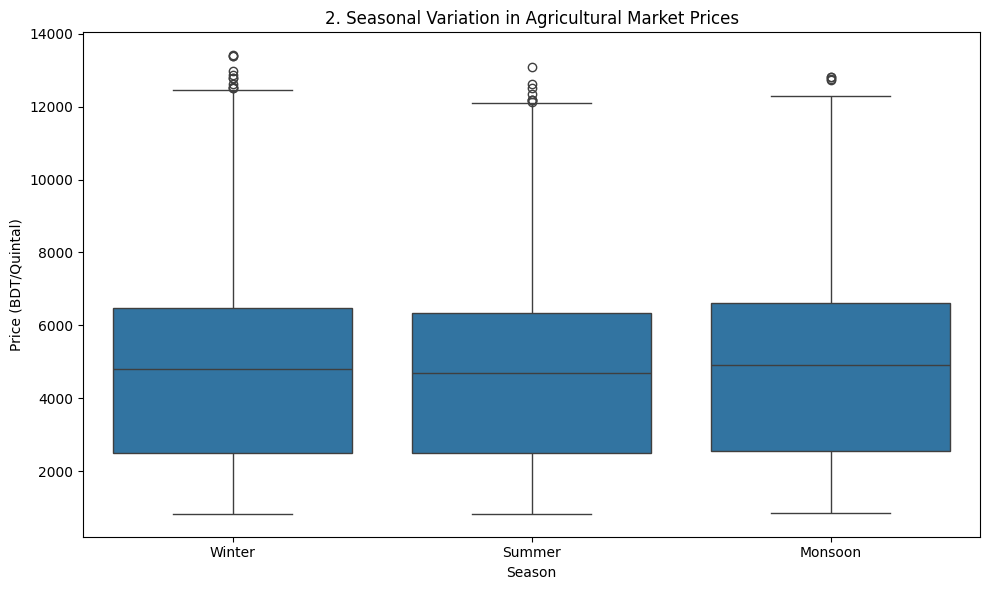

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='Price (BDT/Quintal)')
plt.title(f'{plot_no}. Seasonal Variation in Agricultural Market Prices')
show_fig()
plot_no += 1

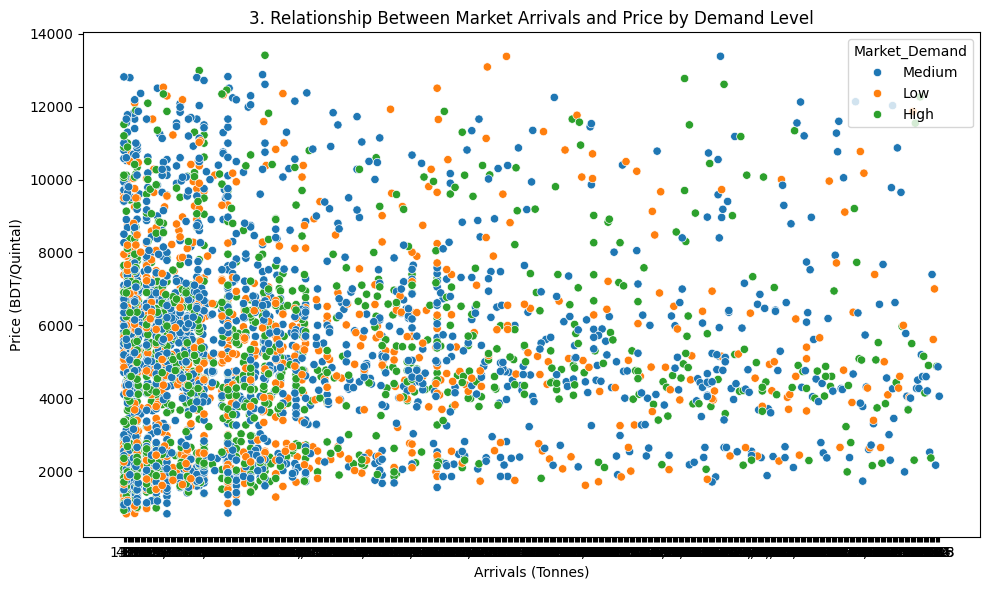

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Arrivals (Tonnes)', y='Price (BDT/Quintal)', hue='Market_Demand')
plt.title(f'{plot_no}. Relationship Between Market Arrivals and Price by Demand Level')
show_fig()
plot_no += 1

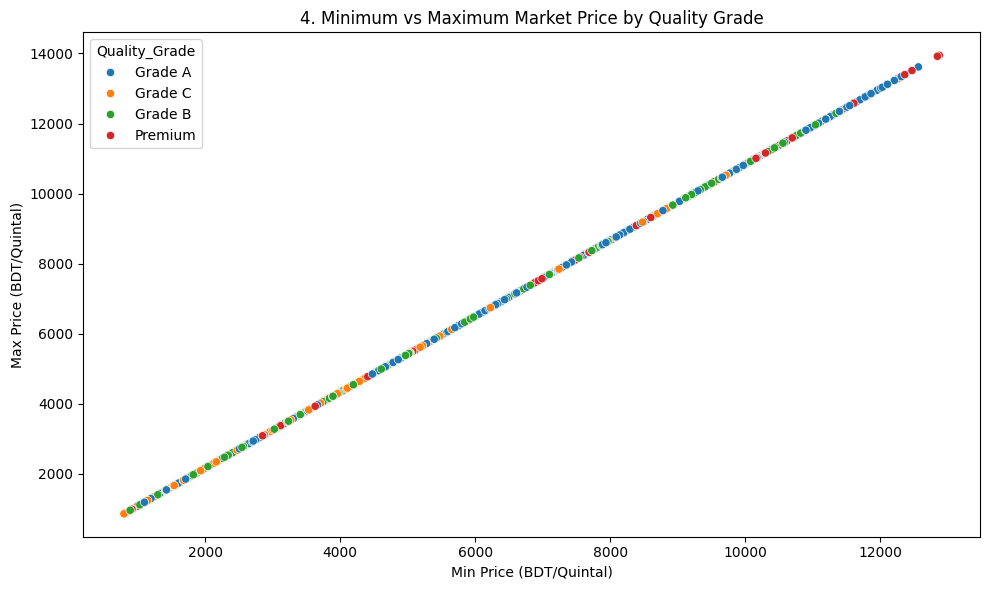

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Min Price (BDT/Quintal)', y='Max Price (BDT/Quintal)', hue='Quality_Grade')
plt.title(f'{plot_no}. Minimum vs Maximum Market Price by Quality Grade')
show_fig()
plot_no += 1

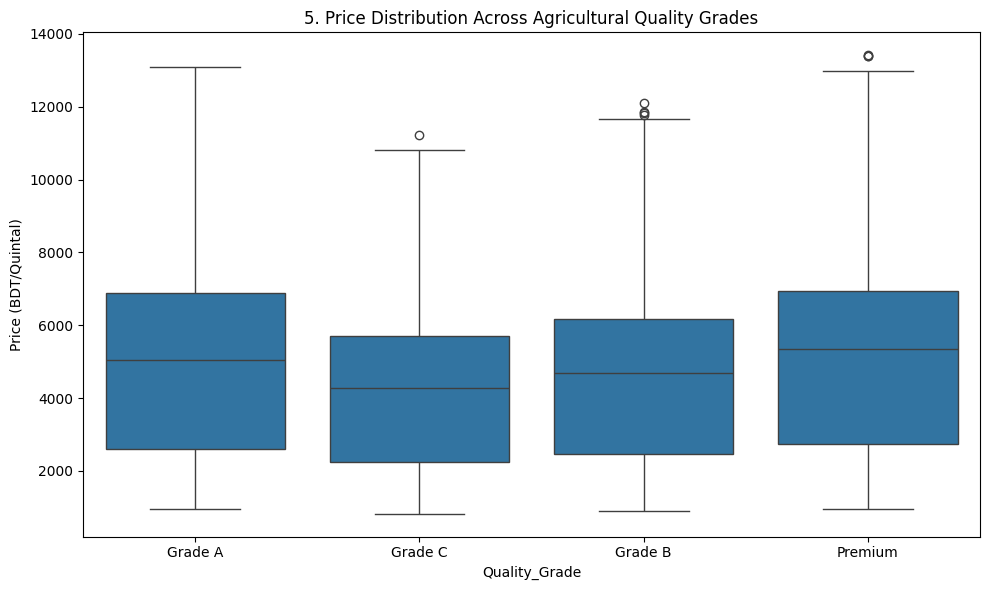

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Quality_Grade', y='Price (BDT/Quintal)')
plt.title(f'{plot_no}. Price Distribution Across Agricultural Quality Grades')
show_fig()
plot_no += 1

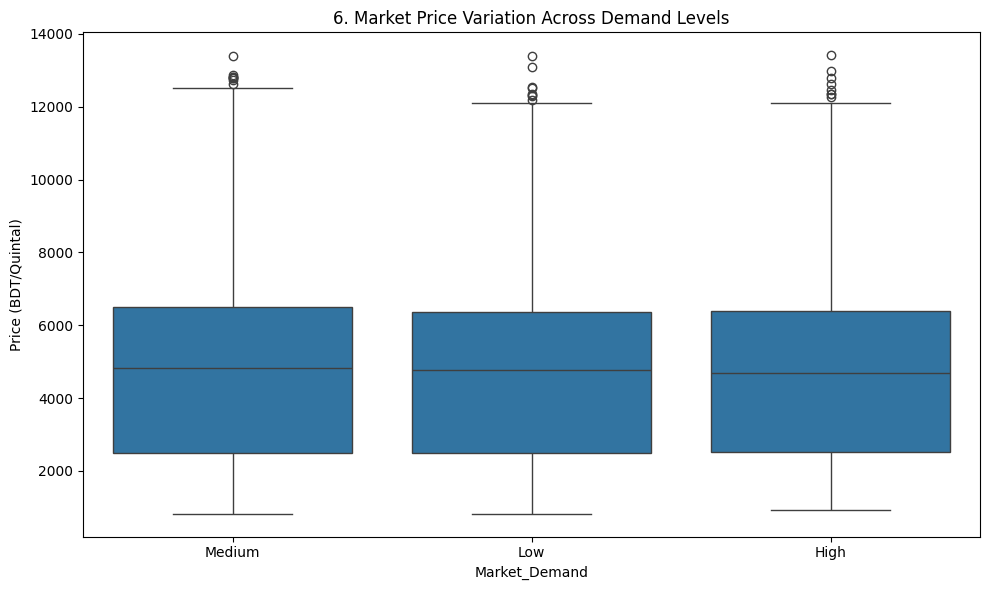

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Market_Demand', y='Price (BDT/Quintal)')
plt.title(f'{plot_no}. Market Price Variation Across Demand Levels')
show_fig()
plot_no += 1

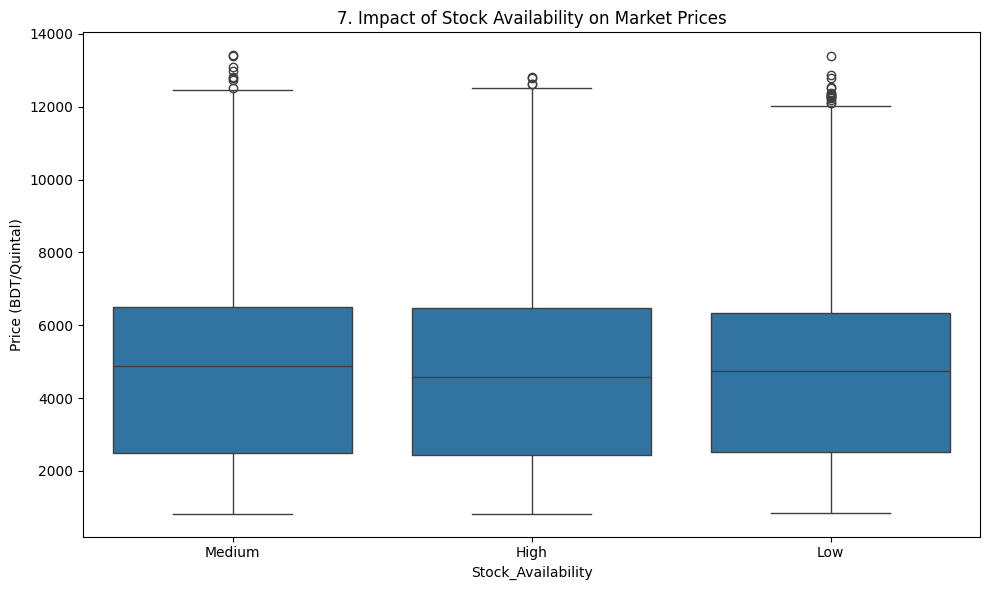

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stock_Availability', y='Price (BDT/Quintal)')
plt.title(f'{plot_no}. Impact of Stock Availability on Market Prices')
show_fig()
plot_no += 1

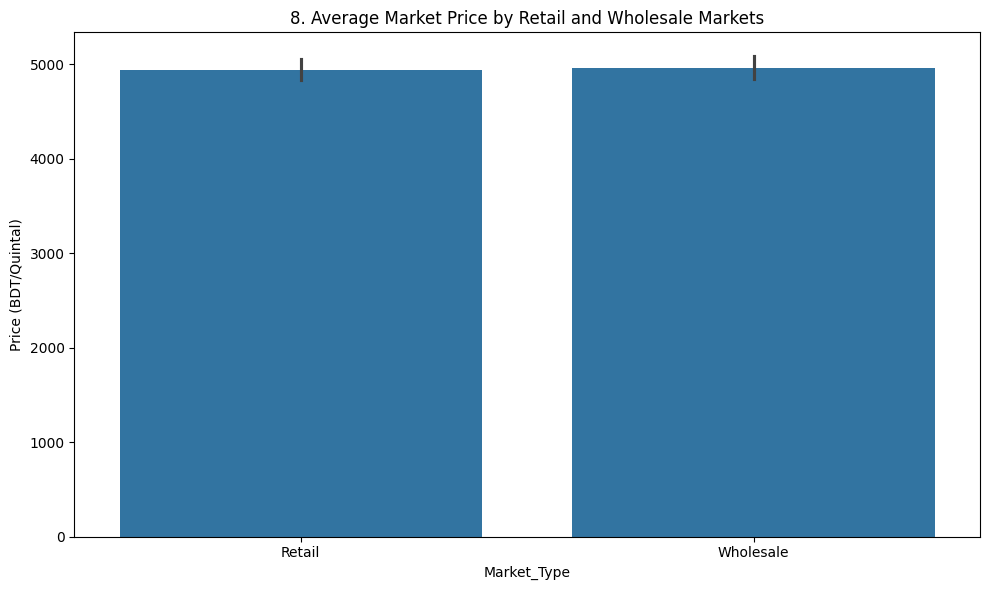

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Market_Type', y='Price (BDT/Quintal)', estimator='mean')
plt.title(f'{plot_no}. Average Market Price by Retail and Wholesale Markets')
show_fig()
plot_no += 1

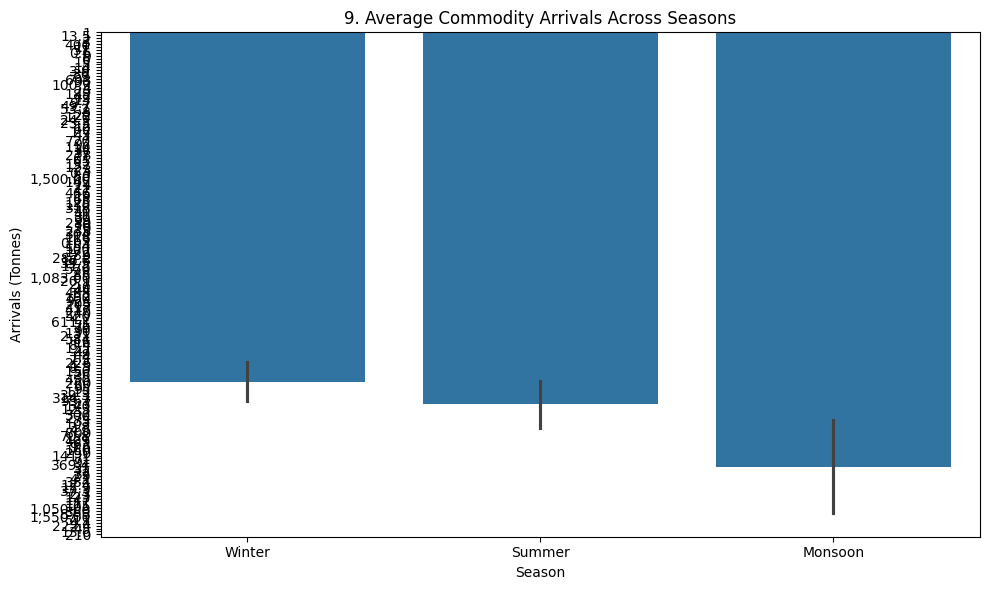

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Season', y='Arrivals (Tonnes)', estimator='mean')
plt.title(f'{plot_no}. Average Commodity Arrivals Across Seasons')
show_fig()
plot_no += 1

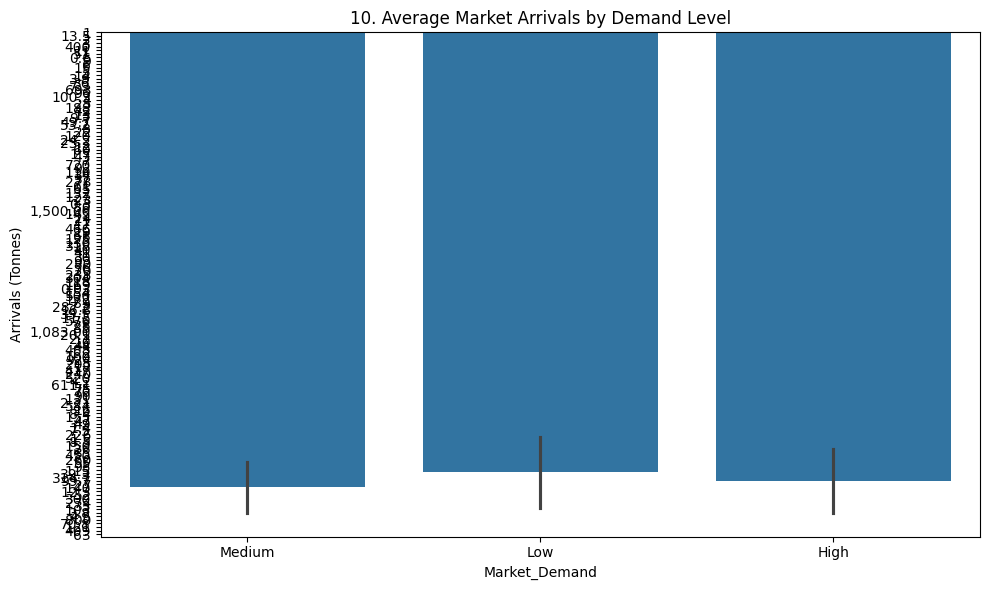

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Market_Demand', y='Arrivals (Tonnes)', estimator='mean')
plt.title(f'{plot_no}. Average Market Arrivals by Demand Level')
show_fig()
plot_no += 1

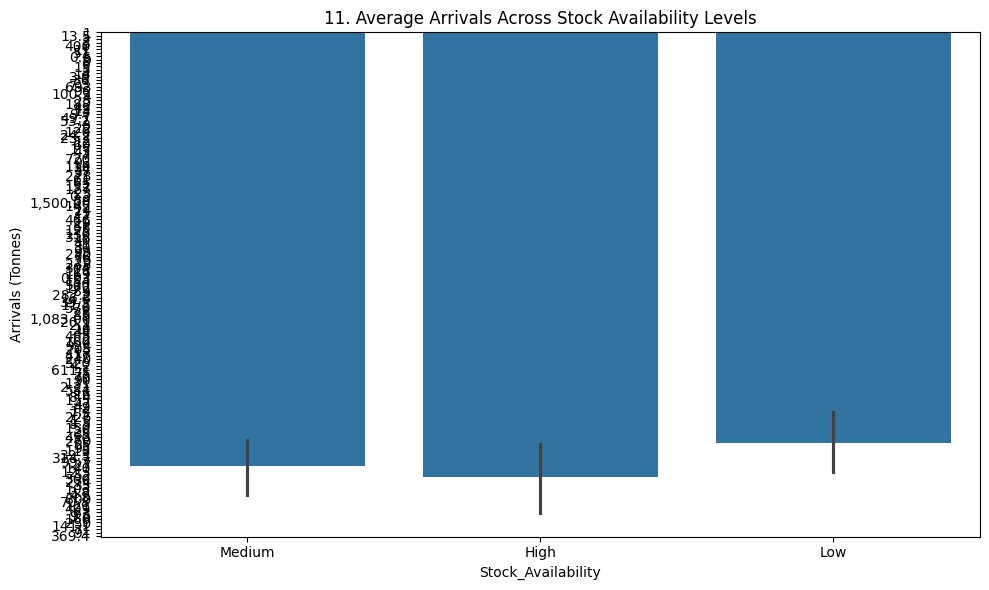

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Stock_Availability', y='Arrivals (Tonnes)', estimator='mean')
plt.title(f'{plot_no}. Average Arrivals Across Stock Availability Levels')
show_fig()
plot_no += 1

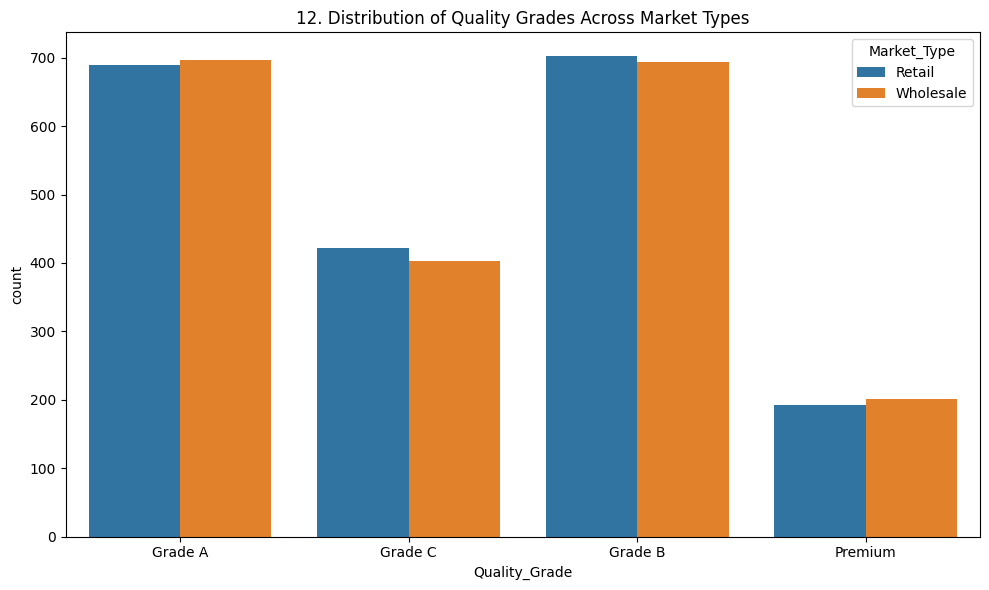

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Quality_Grade', hue='Market_Type')
plt.title(f'{plot_no}. Distribution of Quality Grades Across Market Types')
show_fig()
plot_no += 1

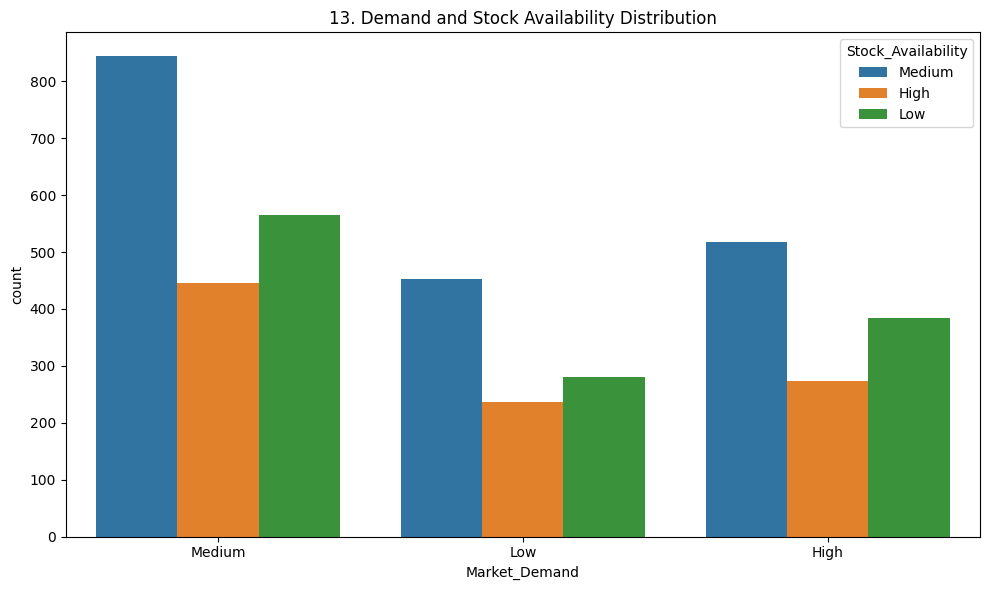

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Market_Demand', hue='Stock_Availability')
plt.title(f'{plot_no}. Demand and Stock Availability Distribution')
show_fig()
plot_no += 1

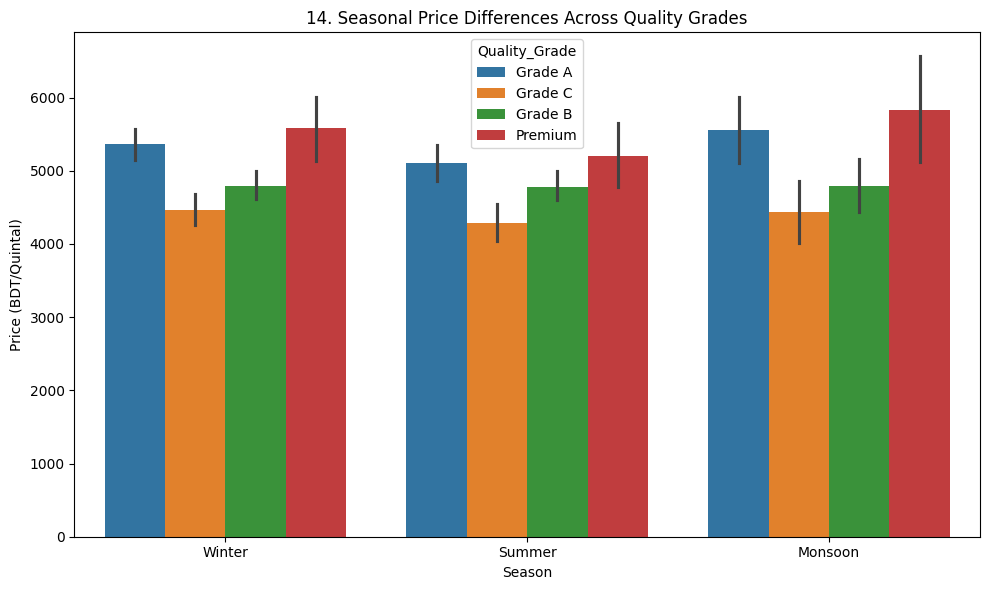

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Season', y='Price (BDT/Quintal)', hue='Quality_Grade', estimator='mean')
plt.title(f'{plot_no}. Seasonal Price Differences Across Quality Grades')
show_fig()
plot_no += 1

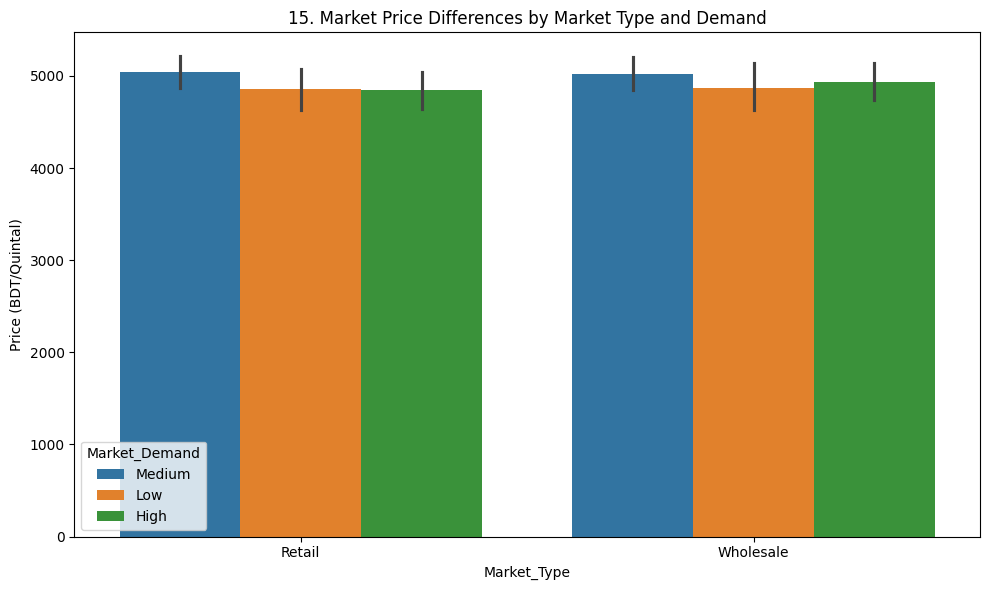

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Market_Type', y='Price (BDT/Quintal)', hue='Market_Demand', estimator='mean')
plt.title(f'{plot_no}. Market Price Differences by Market Type and Demand')
show_fig()
plot_no += 1

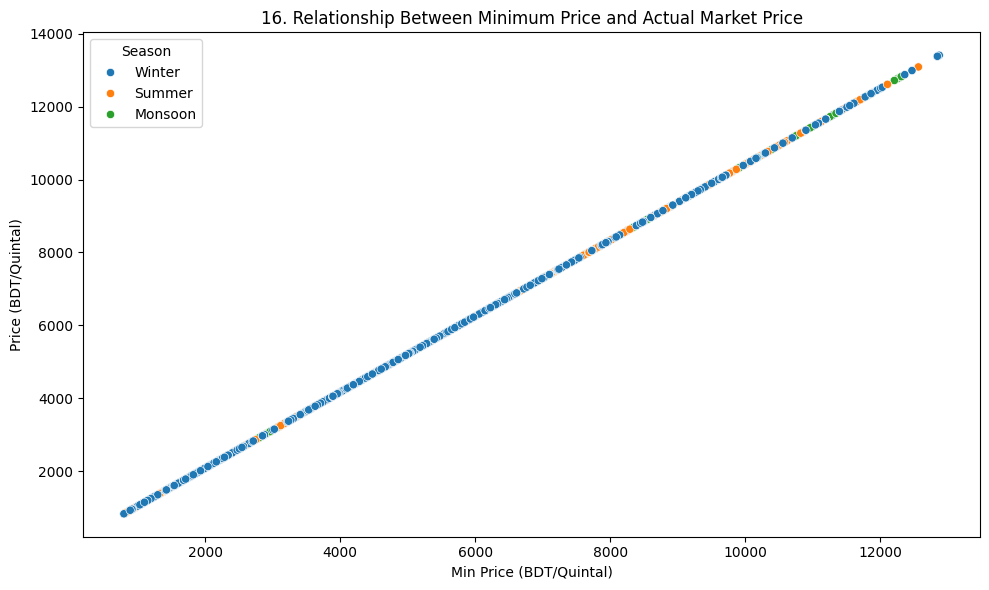

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Min Price (BDT/Quintal)', y='Price (BDT/Quintal)', hue='Season')
plt.title(f'{plot_no}. Relationship Between Minimum Price and Actual Market Price')
show_fig()
plot_no += 1

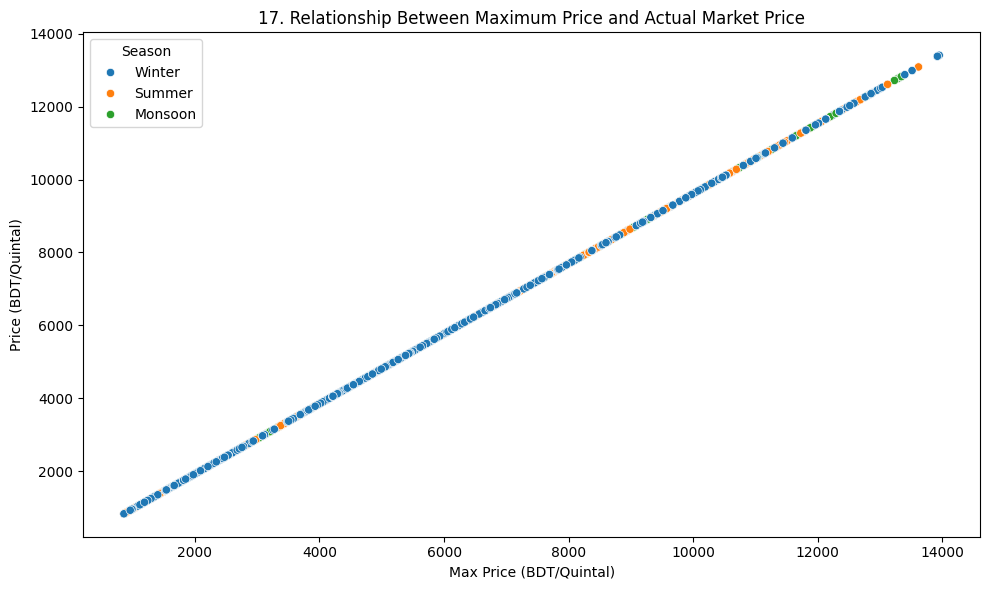

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Max Price (BDT/Quintal)', y='Price (BDT/Quintal)', hue='Season')
plt.title(f'{plot_no}. Relationship Between Maximum Price and Actual Market Price')
show_fig()
plot_no += 1

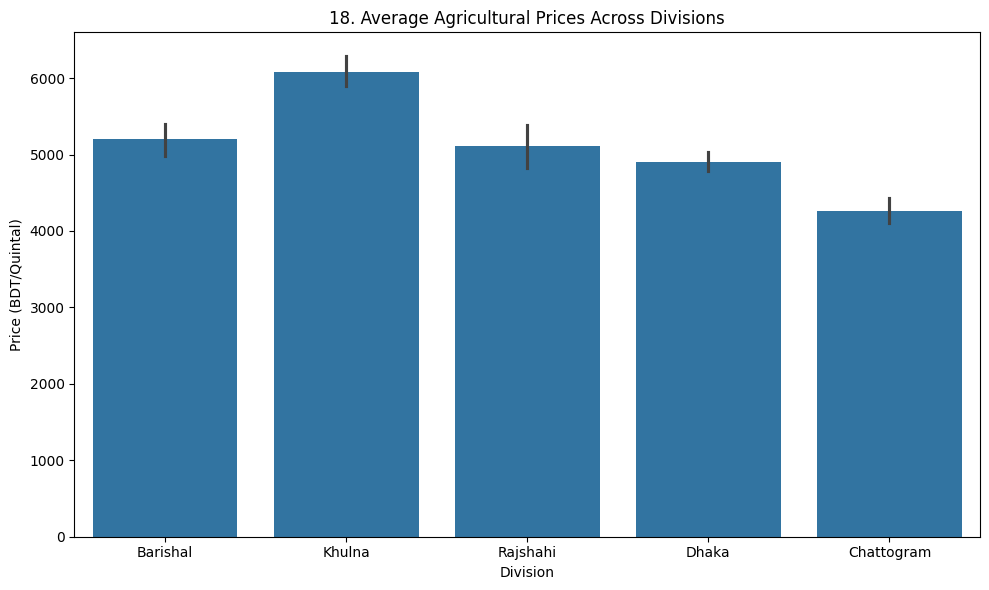

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Division', y='Price (BDT/Quintal)', estimator='mean')
plt.title(f'{plot_no}. Average Agricultural Prices Across Divisions')
show_fig()
plot_no += 1

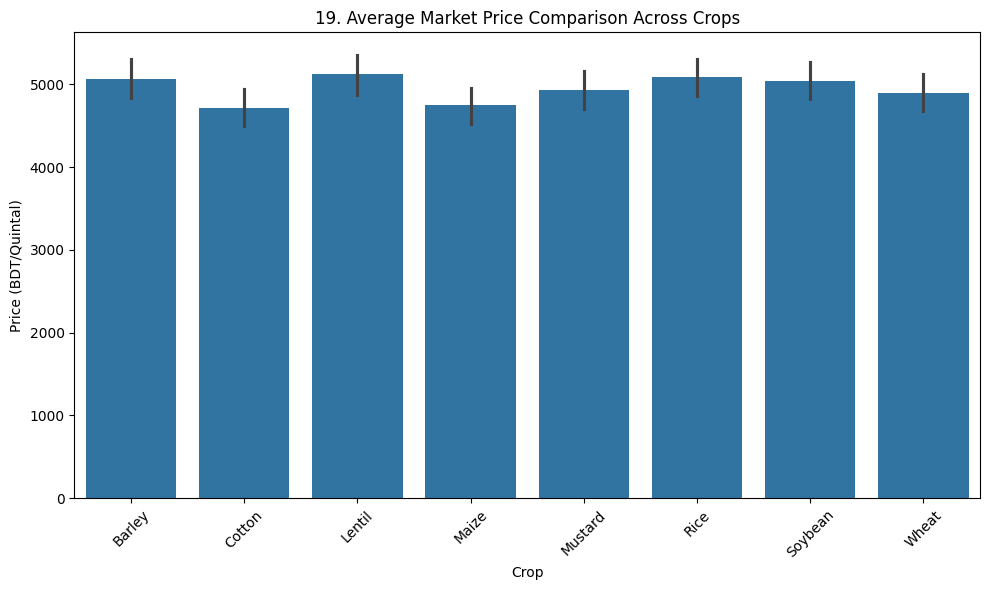

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Crop', y='Price (BDT/Quintal)', estimator='mean')
plt.title(f'{plot_no}. Average Market Price Comparison Across Crops')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

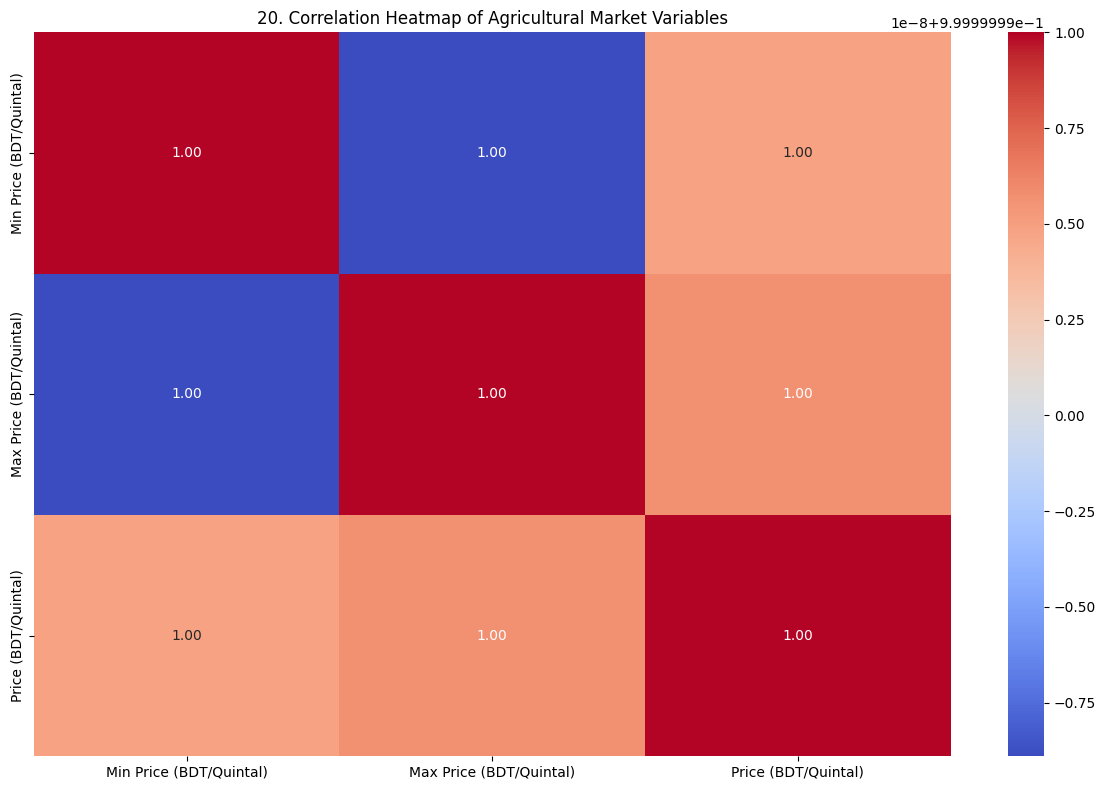

In [32]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Agricultural Market Variables')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [33]:
X = df[['Min Price (BDT/Quintal)', 'Max Price (BDT/Quintal)']]
y = pd.cut(
    df['Price (BDT/Quintal)'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

## Split the dataset

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale the features

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train the supervised classification model

In [36]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Generate predictions

In [37]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 1.0000
Model Accuracy: 100.00%


## Display confusion matrix

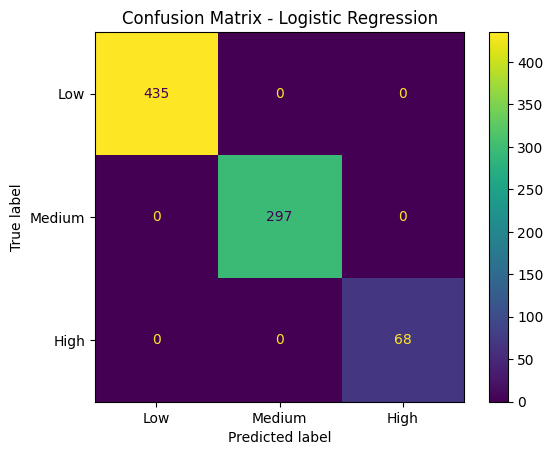

In [39]:
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()